In [94]:
# Adjust import path
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

import os
import numpy as np
import matplotlib.pyplot as plt
import opinf
import config
import utils
import step1_generate_data as step1

In [95]:
normalization = 1e-2

training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .03 # 0
num_regression_points= num_samples * 3 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-3 # 1e-4
ndraws=100 # 100
exportto=None
openonsave=False
ddtdata=False

import numpy as np
import config
config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t 

In [96]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain.shape, true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 3.00% noise
Dimension: retaining 3 POD modes
Training: using 1200 regression points
GP regularization: eta = 1.00e-03
Posterior: 100 draws

generating training data...done in 0.47 s.


((801,), (1024, 801), (400,), (1024, 400))

In [97]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.16 s.


In [98]:
# Fit Gaussian process kernels to the compressed training data.
import step2_fitgps as step2

time_domain_training = np.linspace(
    training_span[0],
    training_span[-1],
    num_regression_points,
)
gps = step2.fit_gaussian_processes(
    time_domain_training=time_domain_training,
    time_domain_sampled=time_domain_sampled,
    snapshots_sampled=snapshots_compressed,
    gp_regularizer=gp_regularizer,
)
q0 = snapshots_compressed[:, 0]


fitting GP model for state 'r_01'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.1359e+02
	\ell = 6.1862e-02
	\chi = 1.6053e-03
done in 30.48 s.
computing weight matrix...done in 0.41 s.

fitting GP model for state 'r_02'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 2.1219e+00
	\ell = 5.0148e-02
	\chi = 1.0318e-04
done in 28.67 s.
computing weight matrix...done in 0.43 s.

fitting GP model for state 'r_03'...
Gaussian radial basis function kernel
	k(t, t') = \sigma^2 exp(-(t - t')^2 / (2 \ell^2)) + \chi I
	\sigma^2 = 1.6785e+00
	\ell = 5.2019e-02
	\chi = 1.5594e-04
done in 28.71 s.
computing weight matrix...done in 0.41 s.


In [99]:
import step3_estimate as step3

import importlib
importlib.reload(step3)

# Create the posterior and fit it 
input_func = config.ReducedOrderModel.input_func
inputs = None if input_func is None else input_func(time_domain_training)
bayesian_model = step3.estimate_posterior(
    time_domain=np.array(time_domain),
    gps=gps,
    inputs=np.array(inputs),
)

constructing posterior hyperparameters...

GRIDSEARCH
(1/81) Testing regularizer 1.0000e-16...87.96% error
(2/81) Testing regularizer 1.7783e-16...87.65% error
(3/81) Testing regularizer 3.1623e-16...87.76% error
(4/81) Testing regularizer 5.6234e-16...87.96% error
(5/81) Testing regularizer 1.0000e-15...87.92% error
(6/81) Testing regularizer 1.7783e-15...88.11% error
(7/81) Testing regularizer 3.1623e-15...87.95% error
(8/81) Testing regularizer 5.6234e-15...87.85% error
(9/81) Testing regularizer 1.0000e-14...87.76% error
(10/81) Testing regularizer 1.7783e-14...87.78% error
(11/81) Testing regularizer 3.1623e-14...87.58% error
(12/81) Testing regularizer 5.6234e-14...87.84% error
(13/81) Testing regularizer 1.0000e-13...87.96% error
(14/81) Testing regularizer 1.7783e-13...87.75% error
(15/81) Testing regularizer 3.1623e-13...87.79% error
(16/81) Testing regularizer 5.6234e-13...87.73% error
(17/81) Testing regularizer 1.0000e-12...87.80% error
(18/81) Testing regularizer 1.7783e-1

In [100]:
# Draw samples from the posterior.

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)

with opinf.utils.TimedBlock("sampling posterior distribution"):
    draws_compressed_training = []
    draws_compressed = []
    qbar = snapshots_compressed.mean(axis=1).reshape((-1, 1))
    bound = 5 * np.max(np.abs(snapshots_compressed - qbar), axis=1)
    num_unstables = 0
    Os = []
    for _ in range(ndraws):
        draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain,
            input_func=input_func,
        )
        training_draw = bayesian_model.predict(
            initial_conditions=q0,
            timepoints=time_domain_eval_training,
            input_func=input_func,
        )
        Os.append(bayesian_model.rvs())
        if draw.shape[1] != time_domain.size or training_draw.shape[1] != time_domain_training.size:
            num_unstables += 1
            continue
        if np.any(np.abs(draw - qbar).max(axis=1) > bound):
            num_unstables += 1
            continue
        draws_compressed_training.append(training_draw)
        draws_compressed.append(draw)
    if num_unstables:
        print(f"\n{num_unstables}/{ndraws} draws unstable")

    # Translate results back to original state space.
    draws = [basis.decompress(draw) for draw in draws_compressed]
    Os = np.array(Os)

sampling posterior distribution...
3/100 draws unstable
done in 1.58 s.


(3, 1) (3, 1) (3, 1)
Number of samples: 1


<Figure size 640x480 with 0 Axes>

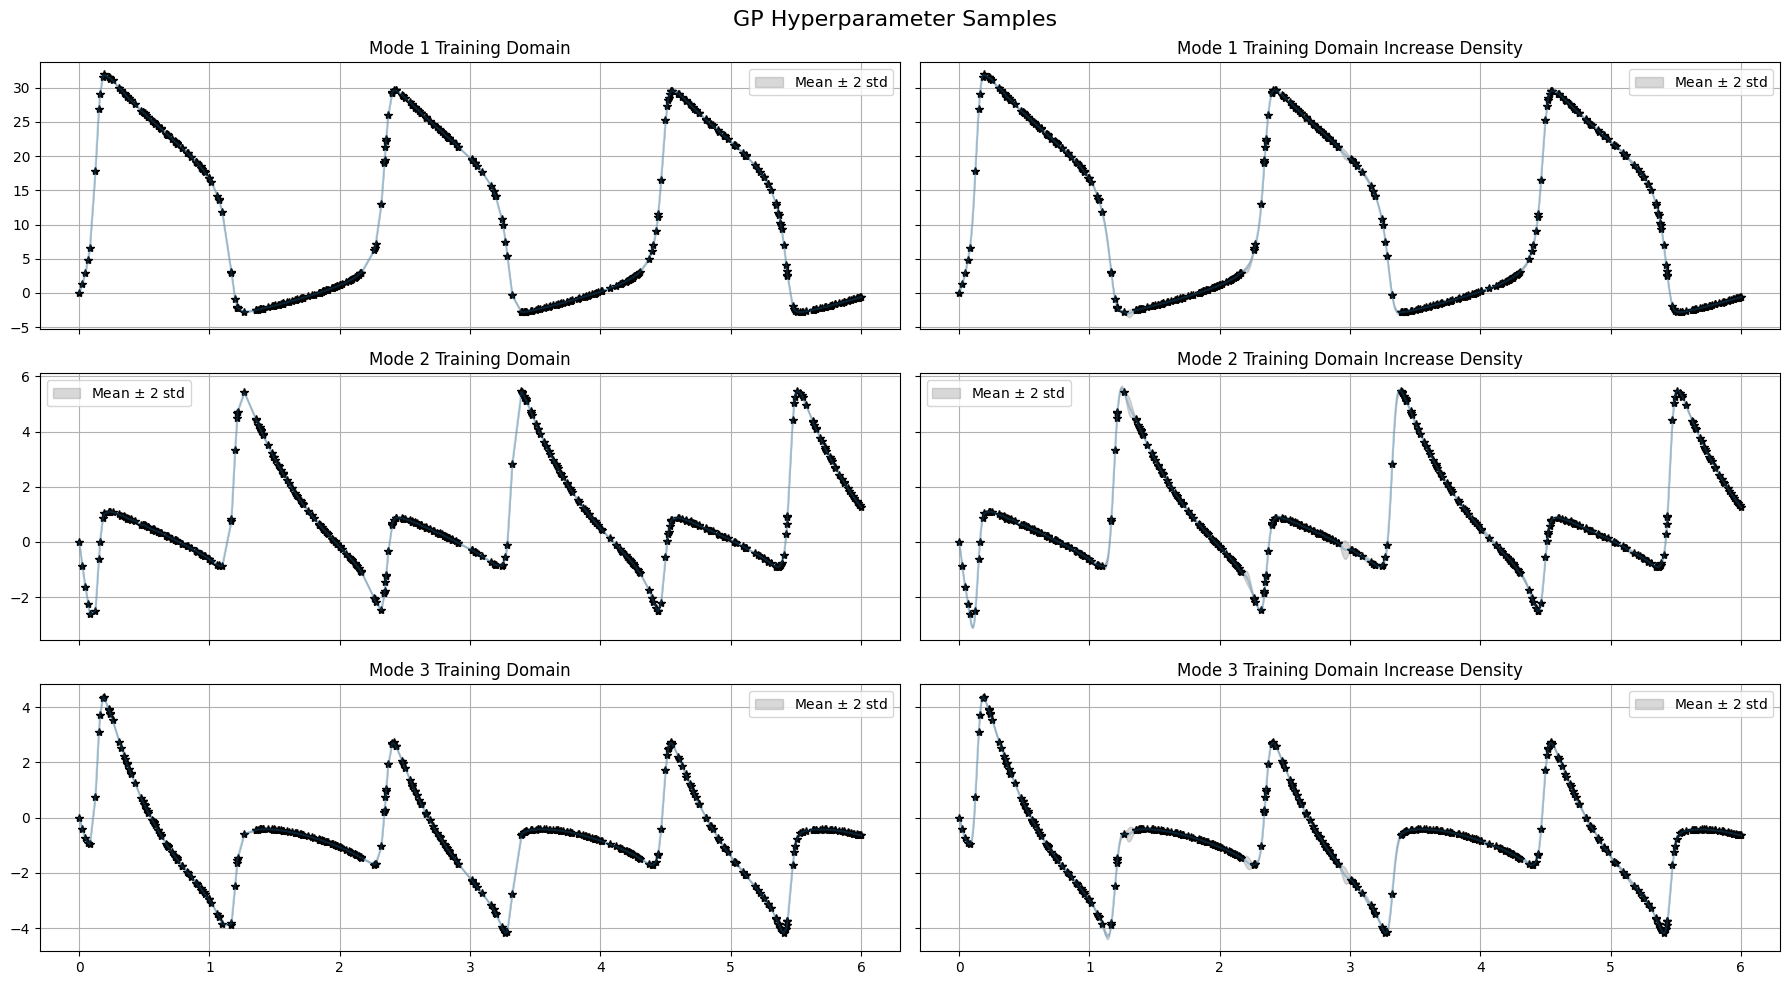

In [101]:
# Plot posterior samples
import fitz_plotter
import importlib
importlib.reload(fitz_plotter)

time_domain_eval_training = np.linspace(0, max(time_domain_sampled), num_regression_points)
time_domain_eval_prediction = np.linspace(0, max(time_domain), int(num_regression_points/max(time_domain_sampled) * max(time_domain)))

lengthscales = np.array([gps[i].gpr.kernel_.k1.k2.length_scale for i in range(numPODmodes)])[:, None]
variances = np.array([gps[i].gpr.kernel_.k1.k1.constant_value for i in range(numPODmodes)])[:, None]
noises = np.array([gps[i].gpr.kernel_.k2.noise_level for i in range(numPODmodes)])[:, None]

print(lengthscales.shape, variances.shape, noises.shape)

plotter = fitz_plotter.FitzPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )

plotter.gp_plot_state(
    lengthscales=lengthscales,
    variances=variances,
    noises=noises,
    max_num_samples=250,
    figsize=(18,10)
)


<Figure size 640x480 with 0 Axes>

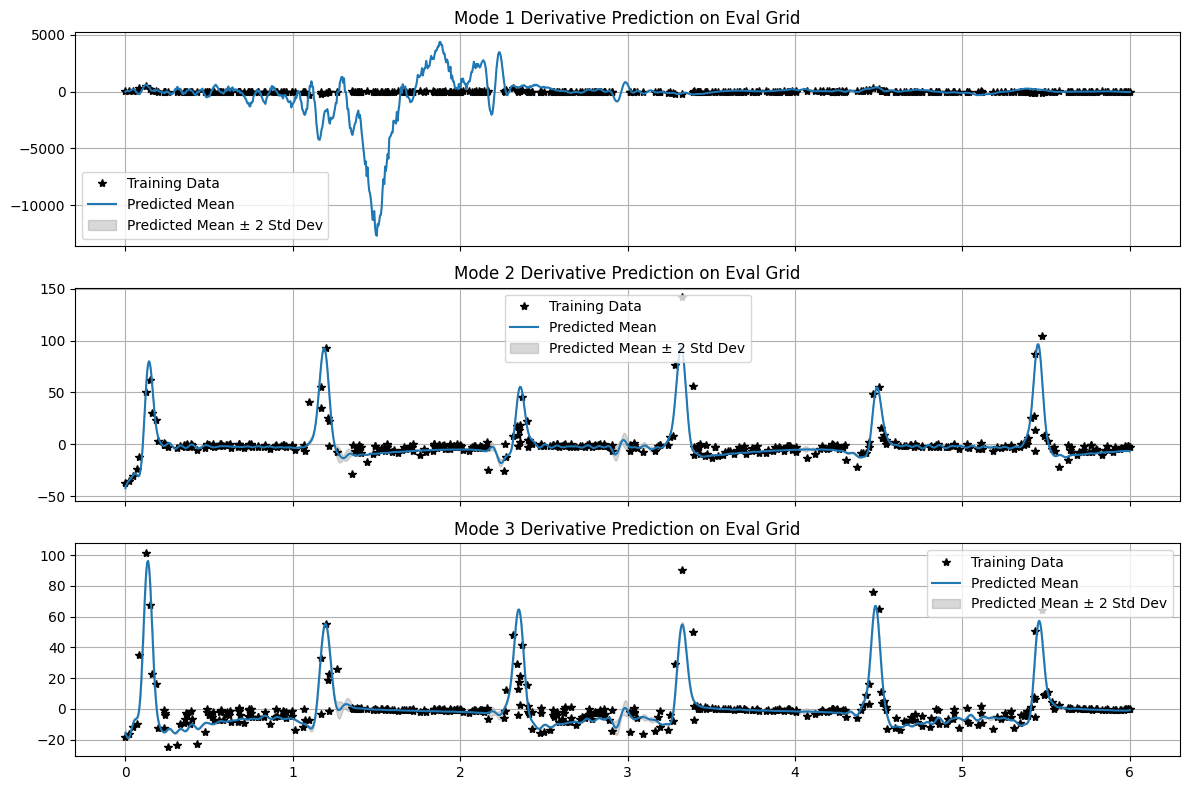

In [102]:

plotter.gp_plot_derivatives()

<Figure size 640x480 with 0 Axes>

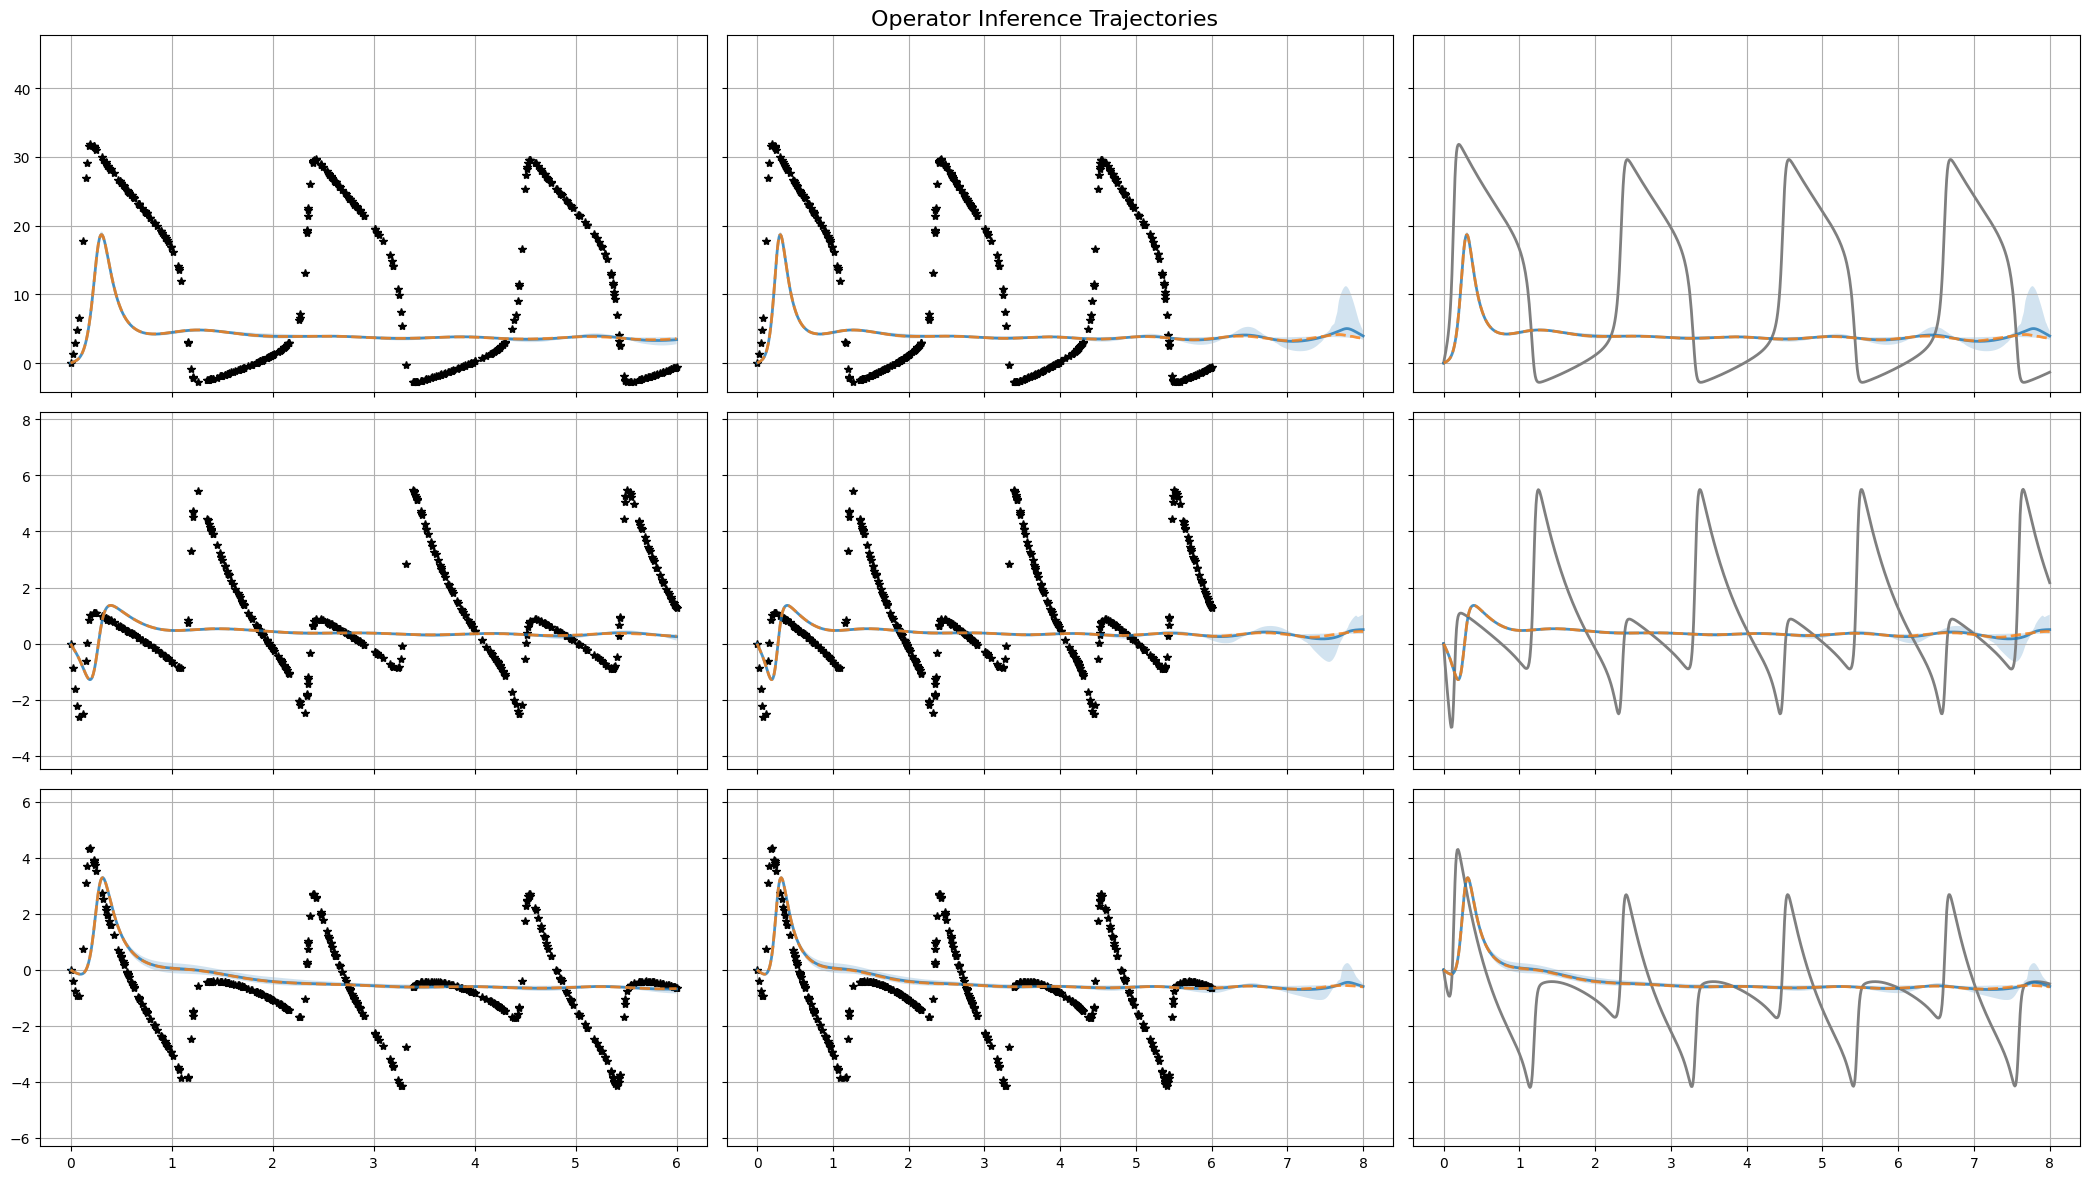

In [103]:
plotter.operator_plot_trajectories(
        draws_training = draws_compressed_training,
        draws_prediction = draws_compressed,
        time_domain_prediction = time_domain,
        figsize=(21, 12),)